# Fine-tuning YOLOv10s — Dataset Unificado

Dataset: ~22.5k imagens, 5 classes (`metal`, `cardboard`, `glass`, `paper`, `plastic`).

Hiperparâmetros:
- `epochs=30` + `patience=20`: dataset maior converge mais rápido por época
- `lr0=0.001` + `cos_lr=True`: LR reduzido para fine-tuning, decaimento cosseno
- `mosaic=0.0`: propriedades visuais de material são sensíveis a contexto
- `freeze=0`: full fine-tuning — domínio diferente do COCO

## 1. Setup

In [1]:
import time
import shutil
import yaml
from pathlib import Path
from ultralytics import YOLO
import torch

print("GPU disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU disponível: True
Tesla T4


## 2. Dataset config (Kaggle)

Estrutura esperada do dataset:
```
.
├── data.yaml
├── train/images  train/labels
├── valid/images  valid/labels
└── test/images   test/labels
```

O `data.yaml` original usa `../train/images` (paths relativos a uma subpasta inexistente).
Reescrevemos somente `path` e os splits — o restante (`nc`, `names`) é preservado.

In [2]:
# Localiza data.yaml dentro de /kaggle/input (busca recursiva)
src_yaml = next(Path("/kaggle/input").glob("**/data.yaml"))
print("data.yaml encontrado em:", src_yaml)

# Copia dataset para área gravável
# (/kaggle/input é read-only; Ultralytics grava .cache ao lado dos labels)
DATASET_DIR = Path("/kaggle/working/dataset")
if not DATASET_DIR.exists():
    shutil.copytree(src_yaml.parent, DATASET_DIR)
    print("Dataset copiado para:", DATASET_DIR)
else:
    print("Dataset já existe em:", DATASET_DIR)

# Lê yaml original e valida
with open(src_yaml) as f:
    data_cfg = yaml.safe_load(f)

assert data_cfg.get("nc") == 5, f"Esperado nc=5, encontrado: {data_cfg.get('nc')}"
expected = {"metal", "cardboard", "glass", "paper", "plastic"}
names_list = data_cfg["names"] if isinstance(data_cfg["names"], list) else list(data_cfg["names"].values())
assert set(names_list) == expected, f"Classes inesperadas: {set(names_list)}"

# Corrige apenas path e splits (preserva nc e names)
data_cfg["path"] = str(DATASET_DIR)
data_cfg["train"] = "train/images"
data_cfg["val"] = "valid/images"
data_cfg["test"] = "test/images"

DATA_YAML = str(DATASET_DIR / "data.yaml")
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_cfg, f)

print("\ndata.yaml final:")
print(yaml.safe_dump(data_cfg))

data.yaml encontrado em: /kaggle/input/datasets/lpstrevisan/dataset-unificado-yolo/Dataset_Unificado_YOLO/data.yaml
Dataset copiado para: /kaggle/working/dataset

data.yaml final:
names:
- metal
- cardboard
- glass
- paper
- plastic
nc: 5
path: /kaggle/working/dataset
test: test/images
train: train/images
val: valid/images



## 3. Sanity check

Valida contagem de imagens/labels por split e plota 3 amostras do treino com bounding boxes.
Evita descobrir erros de path ou label após horas de treino.

In [3]:
for split, rel_path in [("train", "train"), ("val", "valid"), ("test", "test")]:
    img_dir   = DATASET_DIR / rel_path / "images"
    label_dir = DATASET_DIR / rel_path / "labels"
    imgs   = list(img_dir.glob("*.*"))
    labels = list(label_dir.glob("*.txt"))
    print(f"{split:<6}: {len(imgs):>6} imagens | {len(labels):>6} labels")
    assert len(labels) > 0, f"Nenhum label encontrado em {label_dir}"

train :  17039 imagens |  17039 labels
val   :   3144 imagens |   3144 labels
test  :   2186 imagens |   2186 labels


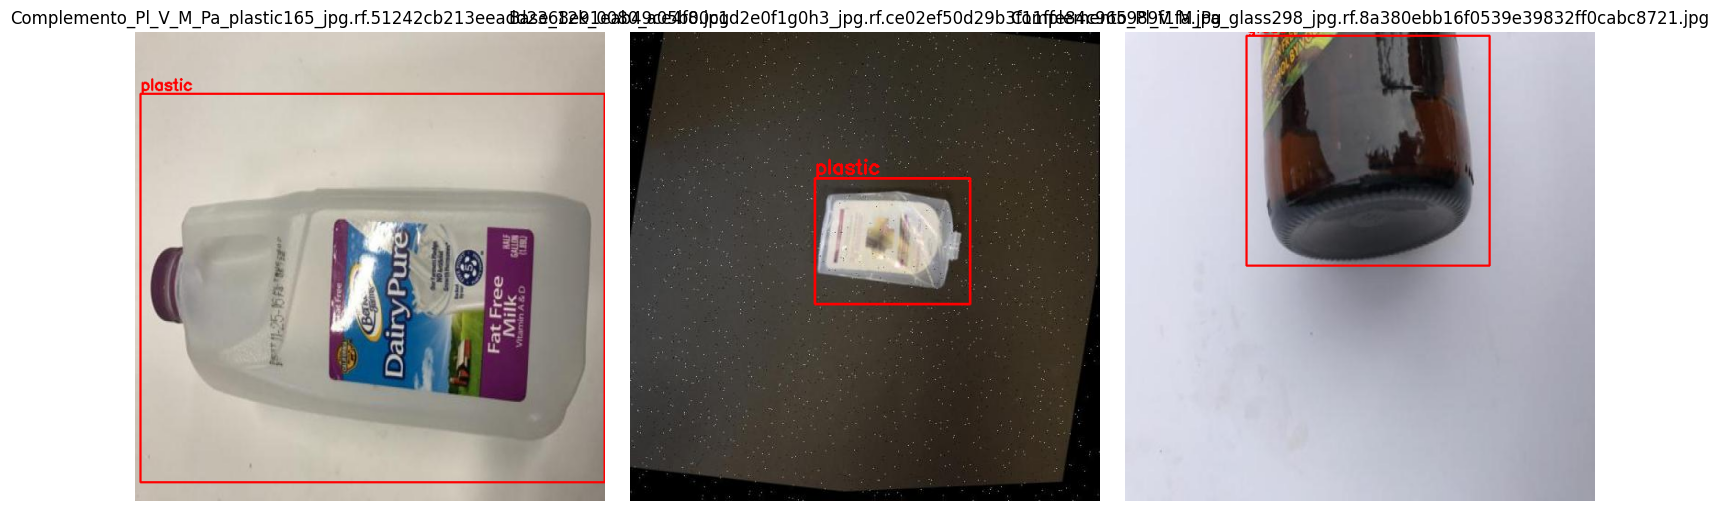

In [4]:
import cv2
import matplotlib.pyplot as plt
import random

train_img_dir   = DATASET_DIR / "train" / "images"
train_label_dir = DATASET_DIR / "train" / "labels"
sample_imgs = random.sample(list(train_img_dir.glob("*.*")), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_path in zip(axes, sample_imgs):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    label_path = train_label_dir / (img_path.stem + ".txt")
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            cls, cx, cy, bw, bh = map(float, line.split())
            x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, names_list[int(cls)], (x1, max(y1-5, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    ax.imshow(img); ax.set_title(img_path.name); ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Fine-tuning

A validação ocorre automaticamente ao final de cada época (`val=True` é o padrão do Ultralytics).
O Ultralytics salva o melhor checkpoint (`best.pt`) baseado no `val/mAP50-95`.

In [5]:
model = YOLO("yolov10s.pt")

start = time.time()
model.train(
    data=DATA_YAML,
    epochs=50,
    patience=20,
    imgsz=640,
    batch=-1,      # autobatch
    lr0=0.001,
    cos_lr=True,
    freeze=0,      # full fine-tuning
    val=True,
    # --- Data Augmentation ---
    # Cor e brilho: simula iluminação variável e reflexos de metal/vidro
    hsv_h=0.015,
    hsv_s=0.8,
    hsv_v=0.5,
    # Orientação: objetos recicláveis não têm orientação canônica
    fliplr=0.5,
    flipud=0.3,
    degrees=15.0,
    # Escala e perspectiva: distância/ângulo de câmera variáveis
    scale=0.5,
    translate=0.1,
    perspective=0.0001,
    # Oclusão e balanceamento de classes
    copy_paste=0.3,  # ajuda especialmente a classe 'paper' (12.7%)
    erasing=0.3,     # simula objetos parcialmente tampados
    # Desativados: destroem contexto visual de material
    mosaic=0.0,
    mixup=0.0,
    # -------------------------
    project="runs",
    name="yolov10s_finetune",
    exist_ok=True,
)
elapsed = time.time() - start
print(f"\nTreino concluído em {elapsed/3600:.1f}h")

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolov10s_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

## 5. Avaliação no conjunto de teste

A validação durante o treino usa `valid/` para guiar o checkpoint. Aqui avaliamos no `test/` (não visto durante o treino) para medir a performance real.

> **Atenção ao `paper`**: é a classe menos representada (12.7% dos objetos). Se o mAP50 dela ficar >5pp abaixo da média, considerar `copy_paste` augmentation numa segunda rodada.

In [6]:
best_weights = Path("runs/detect/runs/yolov10s_finetune/weights/best.pt")
model_eval = YOLO(str(best_weights))
metrics = model_eval.val(data=DATA_YAML, split="test")

print("\nmAP50 por classe:")
for name, ap in zip(names_list, metrics.box.ap50):
    print(f"  {name:<12} {ap:.3f}")
print(f"\nmAP50    (média): {metrics.box.map50:.3f}")
print(f"mAP50-95 (média): {metrics.box.map:.3f}")

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14912MiB)
YOLOv10s summary (fused): 106 layers, 7,219,935 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 553.4±339.1 MB/s, size: 20.5 KB)
val: Scanning /kaggle/working/dataset/test/labels... 2186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2186/2186 1.3Kit/s 1.7s
val: New cache created: /kaggle/working/dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 80, len(boxes) = 5796. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 4.5it/s 30.2s
                   all       2186       5796      0.732      0.556       0.64      0.452
                 metal        349        698      0.793   